# Historical Assignment Attribution Analysis

The original revision plan proposed reconstructing department history from employee `Transfer` events.

The audit found that these events represent location transfers, not department transfers. All 10,000 employees retain their hire department. Department-history attribution bias is therefore zero by construction.

This notebook documents that finding and quantifies the analogous bias caused by assigning historical records to employees' final locations.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display


candidate_roots = [
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = next(
    path
    for path in candidate_roots
    if (
        path
        / "data"
        / "processed"
        / "department_history_bias"
    ).exists()
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "department_history_bias"
)

department_summary = pd.read_csv(
    OUTPUT_DIR / "department_bias_summary.csv"
)

department_groups = pd.read_csv(
    OUTPUT_DIR
    / "department_validation_by_group.csv"
)

transfer_flows = pd.read_csv(
    OUTPUT_DIR / "location_transfer_flows.csv"
)

reassignment = pd.read_csv(
    OUTPUT_DIR
    / "location_reassignment_summary.csv"
)

metric_comparison = pd.read_csv(
    OUTPUT_DIR / "location_metric_comparison.csv"
)

samples = pd.read_csv(
    OUTPUT_DIR / "reassigned_record_samples.csv"
)

print(f"Analysis directory: {OUTPUT_DIR}")

Analysis directory: c:\Users\Yuchen Xu\Documents\workforce-intelligence-platform\data\processed\department_history_bias


In [2]:
display(Markdown("## Department validation"))
display(department_summary)
display(department_groups)

display(Markdown("## Location reassignment"))
display(reassignment)

display(
    Markdown(
        "## Largest location-level changes"
    )
)
display(
    metric_comparison.sort_values(
        "absolute_difference",
        ascending=False,
    ).head(25)
)

display(Markdown("## Example reassigned records"))
display(samples.head(30))

## Department validation

,metric,value
0,Employees checked,10000.0
1,Employees missing hire department,0.0
2,Hire-versus-current department mismatches,0.0
3,Department-transfer events,0.0
4,Department mismatch rate,0.0


,department_name,employees,department_mismatches,mismatch_rate
0,Customer Support,800,0,0.0
1,Engineering,2000,0,0.0
2,Finance,800,0,0.0
3,Human Resources,701,0,0.0
4,Information Technology,1000,0,0.0
5,Manufacturing,2499,0,0.0
6,Sales,1000,0,0.0
7,Supply Chain,1200,0,0.0


## Location reassignment

,domain,total_records,reassigned_records,reassigned_employees,reassignment_rate
0,Training records,26433,1299,553,0.049143
1,Compensation records,30997,1249,553,0.040294
2,Promotion events,2146,74,70,0.034483
3,Leave events,964,32,18,0.033195
4,Performance reviews,17972,558,357,0.031048
5,Manager-change events,632,18,18,0.028481
6,Termination events,1713,0,0,0.000000


## Largest location-level changes

,domain,metric,location,current_value,historical_value,difference,absolute_difference,relative_difference
45,Training records,total_training_hours,Austin,90897.900000,88648.300000,-2249.600000,2249.600000,-0.024749
46,Training records,total_training_hours,Buffalo,39359.000000,41384.700000,2025.700000,2025.700000,0.051467
47,Training records,total_training_hours,Fremont,78868.300000,78117.700000,-750.600000,750.600000,-0.009517
49,Training records,total_training_hours,Reno,54293.800000,54952.600000,658.800000,658.800000,0.012134
41,Compensation records,average_base_salary,Buffalo,88478.428797,88814.834471,336.405674,336.405674,0.003802
48,Training records,total_training_hours,Phoenix,57447.000000,57762.700000,315.700000,315.700000,0.005496
43,Compensation records,average_base_salary,Phoenix,90036.645512,90288.967009,252.321497,252.321497,0.002802
5,Compensation records,record_count,Austin,8749.000000,8538.000000,-211.000000,211.000000,-0.024117
10,Training records,record_count,Austin,7485.000000,7298.000000,-187.000000,187.000000,-0.024983
11,Training records,record_count,Buffalo,3246.000000,3411.000000,165.000000,165.000000,0.050832


## Example reassigned records

,domain,employee_id,record_date,current_location,historical_location
0,Performance reviews,100002,2023-04-03,Austin,Reno
1,Performance reviews,100002,2024-04-03,Austin,Reno
2,Performance reviews,100009,2023-12-06,Reno,Fremont
3,Performance reviews,100011,2023-08-24,Phoenix,Buffalo
4,Performance reviews,100015,2023-12-29,Austin,Phoenix
5,Performance reviews,100035,2024-09-28,Austin,Buffalo
6,Performance reviews,100060,2025-01-16,Austin,Buffalo
7,Performance reviews,100060,2026-01-16,Austin,Buffalo
8,Performance reviews,100096,2023-06-28,Austin,Reno
9,Performance reviews,100185,2024-06-19,Phoenix,Austin


## Reassignment Rate By Domain

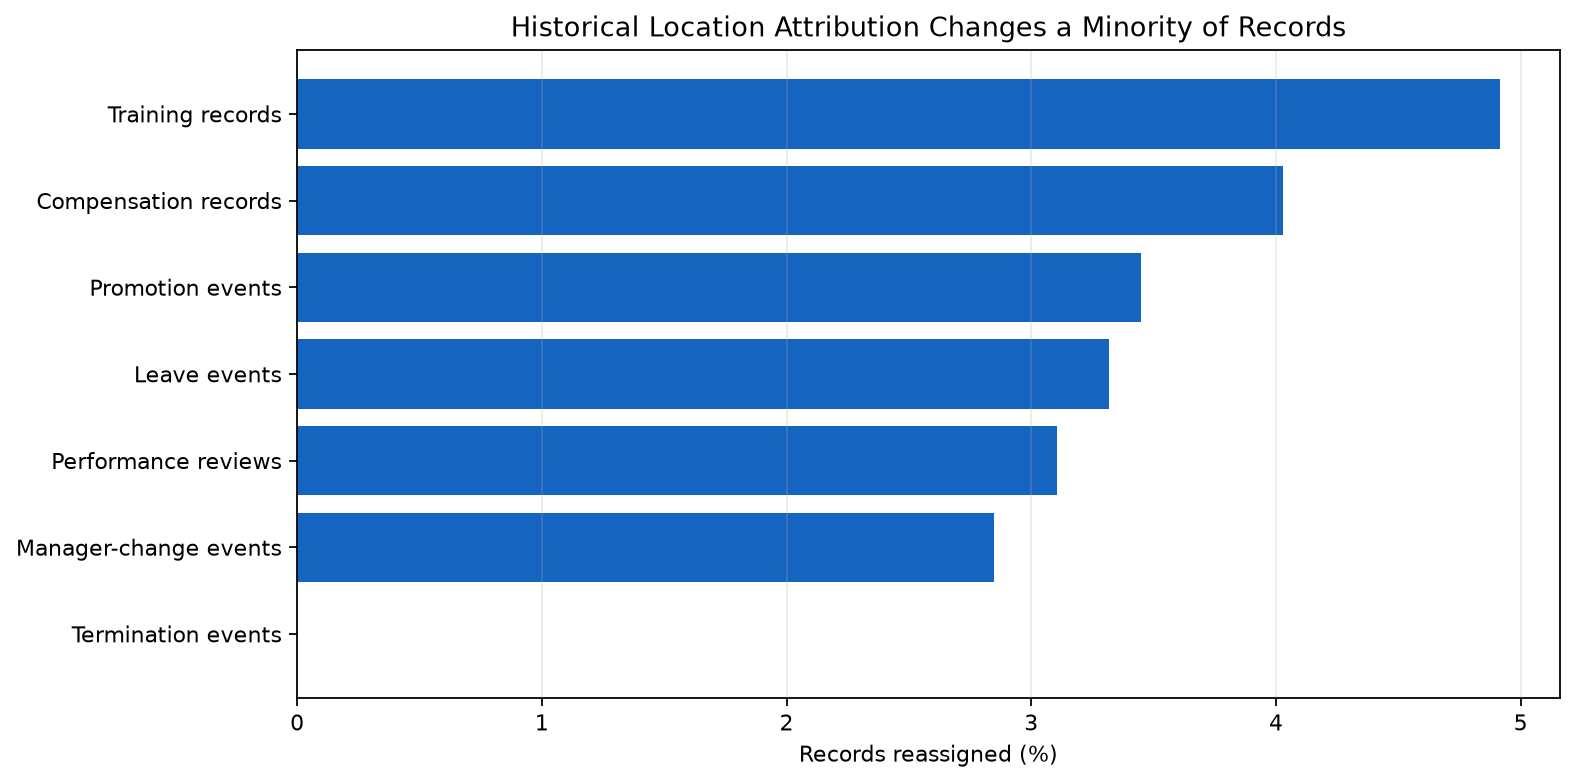

## Current Vs Historical Location

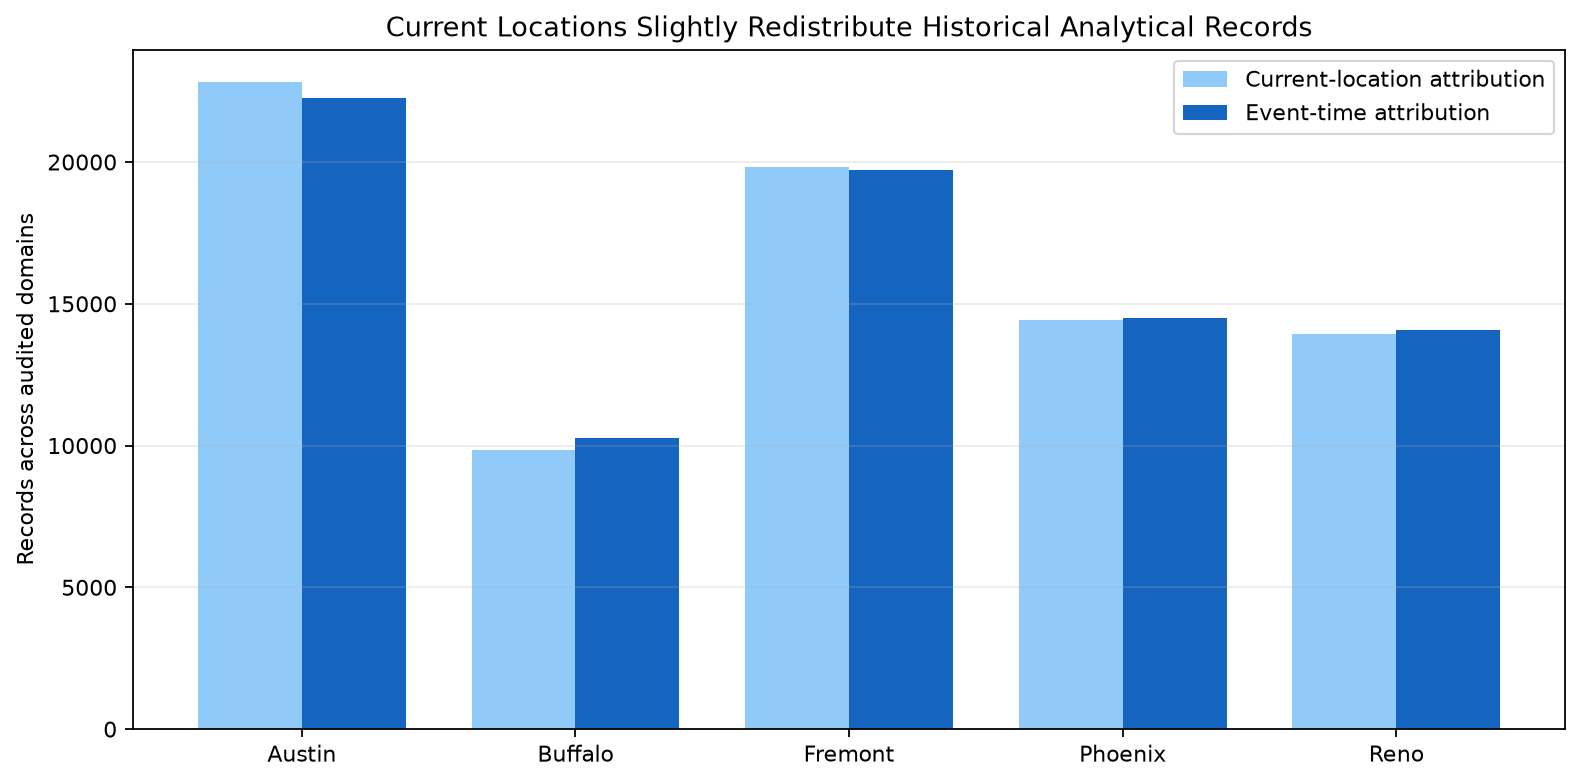

In [3]:
figure_directory = OUTPUT_DIR / "figures"

for figure_path in sorted(
    figure_directory.glob("*.png")
):
    title = (
        figure_path.stem
        .split("_", maxsplit=1)[-1]
        .replace("_", " ")
        .title()
    )

    display(Markdown(f"## {title}"))
    display(
        Image(
            filename=str(figure_path)
        )
    )

## Conclusions

1. All 10,000 employees have matching hire and current departments.
2. Version 1 contains no department-transfer mechanism.
3. Department-history attribution bias is zero by construction.
4. The 553 transfer events represent location changes.
5. Historical location reconstruction changes 2.85%–4.91% of records in most audited domains.
6. Termination attribution does not change because no termination occurs before the employee's generated transfer becomes effective.
7. Current-location attribution shifts historical records toward final destinations, especially Austin, while event-time attribution restores records to former locations such as Buffalo.
8. Location-level historical metrics should use effective-dated assignments.
9. Future synthetic data should store department, location, job-role, and manager histories explicitly.